# Diagnosis Report — Banco_de_sangre,_Hospital_General_de_Medellín_20260821


**Student**: Alba Luz Preciado Pinillo ; Alina Maria Alvarez
**Dataset**: Banco_de_sangre,_Hospital_General_de_Medellín_20260821
**Date**: 28/08/2026


## 0. Setup





In [11]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, re, unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
print('pandas', pd.__version__)

pandas 3.0.5


## 1. Carga

El archivo llega con **todas las columnas como texto**. Se cargan como `str` para no
perder información en el parseo automático, y se convierten explícitamente después.


In [12]:
RUTA = 'Banco_de_sangre,_Hospital_General_de_Medellín_20260821.csv' 

df = pd.read_csv(RUTA, dtype=str, encoding='utf-8')
print(f'CHECK 1 — Forma: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Memoria: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB')
df.head()

CHECK 1 — Forma: 35,840 filas x 11 columnas
Memoria: 20.49 MB


,ANO,TRIMESTRE,FECHA EXTRACCION,RH,BARRIO,CIUDAD,EDAD,ESTATURA,FECHA NACIMIENTO,PESO,SEXO
0,2020,4,28/12/2020,0+,POPULAR 1,MEDELLIN,41,NaN,1982 Jan 01 12:00:00 AM,NaN,M
1,2020,1,01/02/2020,0+,20 DE JULIO,MEDELLIN,43,1.74,1979 Mar 12 12:00:00 AM,80,M
2,2020,1,01/02/2020,0+,20 DE JULIO,MEDELLIN,43,1.74,1979 Mar 12 12:00:00 AM,80,M
3,2020,1,01/02/2020,0+,20 DE JULIO,MEDELLIN,44,1.6,1979 Apr 21 12:00:00 AM,86,F
4,2020,1,01/02/2020,0+,20 DE JULIO,MEDELLIN,44,1.6,1979 Apr 21 12:00:00 AM,86,F


In [13]:
from pathlib import Path
for f in Path('.').iterdir():
    print(repr(f.name))

'.git'
'.venv'
'4-preparation_handbook.ipynb'
'Banco_de_sangre,_Hospital_General_de_Medellín_20260821.csv'
'diagnostico_datos.ipynb'
'README.md'
'requirements.txt'


In [14]:

print("--- Porcentaje de Nulos por Columna ---")
nulos_pct = (df.isna().sum() / len(df)) * 100
print(nulos_pct[nulos_pct > 0].sort_values(ascending=False).to_string())
print("\n")

# Diagnóstico cruzado: ¿El BARRIO es nulo porque la CIUDAD no es Medellín?
df['BARRIO_NULO'] = df['BARRIO'].isna()
cruce_barrio_ciudad = pd.crosstab(df['CIUDAD'] == 'MEDELLIN', df['BARRIO_NULO'], 
                                  rownames=['Es Medellín'], colnames=['Falta Barrio'], normalize='index') * 100
print("--- Probabilidad de nulo en BARRIO según CIUDAD ---")
print(cruce_barrio_ciudad.round(2).astype(str) + ' %')

--- Porcentaje de Nulos por Columna ---
BARRIO              21.729911
ESTATURA             0.220424
RH                   0.114397
PESO                 0.114397
EDAD                 0.005580
FECHA NACIMIENTO     0.005580
SEXO                 0.002790


--- Probabilidad de nulo en BARRIO según CIUDAD ---
Falta Barrio    False    True 
Es Medellín                   
False         68.14 %  31.86 %
True          79.86 %  20.14 %


Diagnóstico de Completitud y Comportamiento de Nulos

Variables de Signos Vitales y Demografía: La calidad de captura en origen es excelente. Los nulos en ESTATURA, PESO, EDAD y RH son estadísticamente insignificantes (inferiores al 0.25%).

Variable Crítica (BARRIO): Presenta un 21.7% de datos faltantes, siendo el único problema real de completitud estructural en el dataset.

Diagnóstico de Dependencia (Crosstab): La ausencia de datos en el barrio no es completamente aleatoria (comportamiento MAR - Missing At Random).

Cuando el donante no reside en Medellín, la probabilidad de que el barrio sea nulo se eleva al 31.86%, lo cual es lógico dado que muchos municipios externos operan con veredas o no tienen divisiones de barrios claramente definidas en el sistema.

Sin embargo, cuando el donante sí es de Medellín, la omisión sigue siendo del 20.14%.

Decisión de Negocio: La falta de BARRIO obedece tanto a factores geográficos (foráneos) como a una falla sistémica en la obligatoriedad del campo al momento del registro en el banco de sangre. Para la etapa de preparación, los nulos de esta columna se imputarán con la categoría "NO REGISTRA", ya que no se pueden inferir y eliminar el 21% del dataset comprometería el análisis. Las columnas redundantes en texto serán eliminadas de memoria.

## 2. Tipos: todo llega como texto

**CHECK 2** — las 11 columnas vienen como `object`. Cuatro son numéricas y dos son
fechas, en dos formatos distintos:

In [15]:
print('CHECK 2 — dtypes originales')
print(df.dtypes.value_counts().to_string())
print()

df['EDAD_n']     = pd.to_numeric(df['EDAD'], errors='coerce')
df['PESO_n']     = pd.to_numeric(df['PESO'], errors='coerce')
df['ESTATURA_n'] = pd.to_numeric(df['ESTATURA'], errors='coerce')
df['ANO_n']      = pd.to_numeric(df['ANO'], errors='coerce')
df['TRIM_n']     = pd.to_numeric(df['TRIMESTRE'], errors='coerce')
df['F_EXT'] = pd.to_datetime(df['FECHA EXTRACCION'], format='%d/%m/%Y', errors='coerce')
df['F_NAC'] = pd.to_datetime(df['FECHA NACIMIENTO'], format='%Y %b %d %I:%M:%S %p', errors='coerce')

for orig, nuevo in [('EDAD','EDAD_n'), ('PESO','PESO_n'), ('ESTATURA','ESTATURA_n'),
                    ('FECHA EXTRACCION','F_EXT'), ('FECHA NACIMIENTO','F_NAC')]:
    fallo = (df[nuevo].isna() & df[orig].notna()).sum()
    print(f'  {orig:<20} no convertidos: {fallo:,}')

CHECK 2 — dtypes originales
str     11
bool     1

  EDAD                 no convertidos: 0
  PESO                 no convertidos: 0
  ESTATURA             no convertidos: 0
  FECHA EXTRACCION     no convertidos: 0
  FECHA NACIMIENTO     no convertidos: 0


**INFO columnas

In [16]:
pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'no_nulos': df.notna().sum(),
    'nulos': df.isna().sum(),
    'unicos': df.nunique(),
})

,dtype,no_nulos,nulos,unicos
ANO,str,35840,0,6
TRIMESTRE,str,35840,0,4
FECHA EXTRACCION,str,35840,0,1335
RH,str,35799,41,8
BARRIO,str,28052,7788,1274
CIUDAD,str,35840,0,28
EDAD,str,35838,2,55
ESTATURA,str,35761,79,72
FECHA NACIMIENTO,str,35838,2,13393
PESO,str,35799,41,99


In [17]:
# 1. Integridad de Fechas vs Edad declarada
edad_calculada = (df['F_EXT'] - df['F_NAC']).dt.days / 365.25
diferencia_edad = (edad_calculada - df['EDAD_n']).abs()

errores_edad = (diferencia_edad > 1).sum() # Tolerancia de 1 año por años bisiestos/redondeos
print(f"Registros donde la EDAD no coincide con FECHA NACIMIENTO: {errores_edad:,} ({(errores_edad/len(df))*100:.1f}%)")

# 2. Límites fisiológicos (Outliers extremos)
print("\n--- Estadísticas Fisiológicas (Detección de Anomalías) ---")
print(df[['EDAD_n', 'PESO_n', 'ESTATURA_n']].describe().loc[['min', 'max']])

# Conteos fuera de rangos legales/lógicos para donación
menores_edad = (df['EDAD_n'] < 18).sum()
mayores_edad = (df['EDAD_n'] > 65).sum()
peso_bajo = (df['PESO_n'] < 50).sum()
estatura_irreal = (df['ESTATURA_n'] < 1.40).sum()

print(f"\nDonantes < 18 años: {menores_edad}")
print(f"Donantes > 65 años: {mayores_edad}")
print(f"Pesos < 50kg: {peso_bajo}")
print(f"Estaturas < 1.40m: {estatura_irreal}")

Registros donde la EDAD no coincide con FECHA NACIMIENTO: 16,534 (46.1%)

--- Estadísticas Fisiológicas (Detección de Anomalías) ---
     EDAD_n  PESO_n  ESTATURA_n
min    14.0    50.0        1.00
max   104.0   171.0        2.03

Donantes < 18 años: 2
Donantes > 65 años: 151
Pesos < 50kg: 0
Estaturas < 1.40m: 12


**Diagnóstico de Consistencia y Reglas de Negocio**

*   **Falla de Integridad en Fechas (Severidad Alta):** El 46.1% de los registros (16,534 casos) presenta discrepancias entre la `EDAD` capturada en el sistema y la edad matemática real (calculada a partir de la `FECHA NACIMIENTO` y `FECHA EXTRACCION`). 
    *   *Decisión:* La columna `EDAD` original carece de confiabilidad analítica. Para la fase de preparación, esta variable debe ser descartada y recalculada dinámicamente usando las fechas.
*   **Violación de Normativas y Límites Fisiológicos (Outliers):**
    *   **Edad de Donación:** Existen edades de 14 y 104 años. Se detectaron 2 menores de edad y 151 personas mayores de 65 años, rompiendo los umbrales legales y médicos estándar para donación de sangre.
    *   **Estatura:** Se evidencian errores de digitación severos con valores físicamente imposibles para adultos (mínimo de 1.00m). Hay 12 registros por debajo de 1.40m que contaminarían cualquier análisis estadístico.
    *   **Peso:** El sistema de origen parece tener una restricción dura o validación de formulario para el peso mínimo, ya que hay 0 casos por debajo del umbral de 50 kg. El valor máximo (171 kg) es un valor extremo pero biológicamente posible.
    *   *Decisión:* Las estaturas anómalas y las edades fuera de los umbrales de política pública (18-65 años) deben ser filtradas o transformadas a nulos (`NaN`) en el pipeline de preparación para evitar sesgos en el modelado posterior.

In [18]:
print("--- Valores Únicos en factor RH ---")
print(df['RH'].unique())

print("\n--- Top 10 Barrios más frecuentes ---")
print(df['BARRIO'].value_counts().head(10))

print("\n--- Bottom 10 Barrios (Posibles errores de tipeo) ---")
print(df['BARRIO'].value_counts().tail(10))

print("\n--- Dispersión de Ciudades ---")
print(f"Total ciudades únicas: {df['CIUDAD'].nunique()}")
print(df['CIUDAD'].value_counts().head(5))

--- Valores Únicos en factor RH ---
<StringArray>
['0+', '0-', 'AB+', 'B+', 'A+', 'A-', 'AB-', 'B-', nan]
Length: 9, dtype: str

--- Top 10 Barrios más frecuentes ---
BARRIO
ROBLEDO         995
MANRIQUE        813
BELEN           798
POBLADO         698
BUENOS AIRES    664
NIQUIA          664
SAN JAVIER      421
CASTILLA        414
ARANJUEZ        360
LOS COLORES     353
Name: count, dtype: int64

--- Bottom 10 Barrios (Posibles errores de tipeo) ---
BARRIO
BELEN LA INMACULADA    1
BRICENO                1
SAN SEBASTIAN          1
CALLE ROBLEDO          1
LOS ARAQUES            1
TERRANOVA 2            1
CALLE NARINO           1
PUERTO ALEGRE          1
DIAMANTE.              1
ALTOS DE LOS ROQUE     1
Name: count, dtype: int64

--- Dispersión de Ciudades ---
Total ciudades únicas: 28
CIUDAD
MEDELLIN    30972
BELLO        1867
ENVIGADO     1028
ITAGUI        397
YARUMAL       264
Name: count, dtype: int64


**Diagnóstico de Cardinalidad y Estandarización de Texto**

*   **Error Tipográfico en Factor RH (Severidad Media):** Existe un error sistemático de captura en el sistema de origen. Se utilizó el dígito numérico `0` (cero) en lugar de la letra `O` para registrar los grupos sanguíneos (`0+`, `0-`).
    *   *Decisión:* Aplicar un reemplazo de caracteres (`0` -> `O`) en el notebook de preparación para estandarizar la nomenclatura médica universal.
*   **Inconsistencia de Granularidad en Barrios (Severidad Alta):** La variable `BARRIO` sufre de entrada libre sin validación, lo que genera una alta cardinalidad artificial. 
    *   Los registros más frecuentes agrupan comunas o macro-sectores enteros (Robledo, Belén, Manrique). 
    *   Los registros de baja frecuencia (cola de la distribución) revelan direcciones mal ingresadas (ej. "CALLE ROBLEDO"), micro-barrios sin estandarizar ("BELEN LA INMACULADA") y nombres de municipios foráneos colocados erróneamente en el campo de barrio ("BRICENO").
    *   *Decisión:* Se requerirá un proceso de limpieza difusa (ej. `RapidFuzz`) para unificar variaciones tipográficas, o agrupar los registros a nivel de Comuna mediante un diccionario de homologación.
*   **Concentración de Ciudades:** La distribución geográfica es congruente con el área de influencia del Hospital General, concentrándose fuertemente en Medellín y los municipios del Valle de Aburrá (Bello, Envigado, Itagüí).

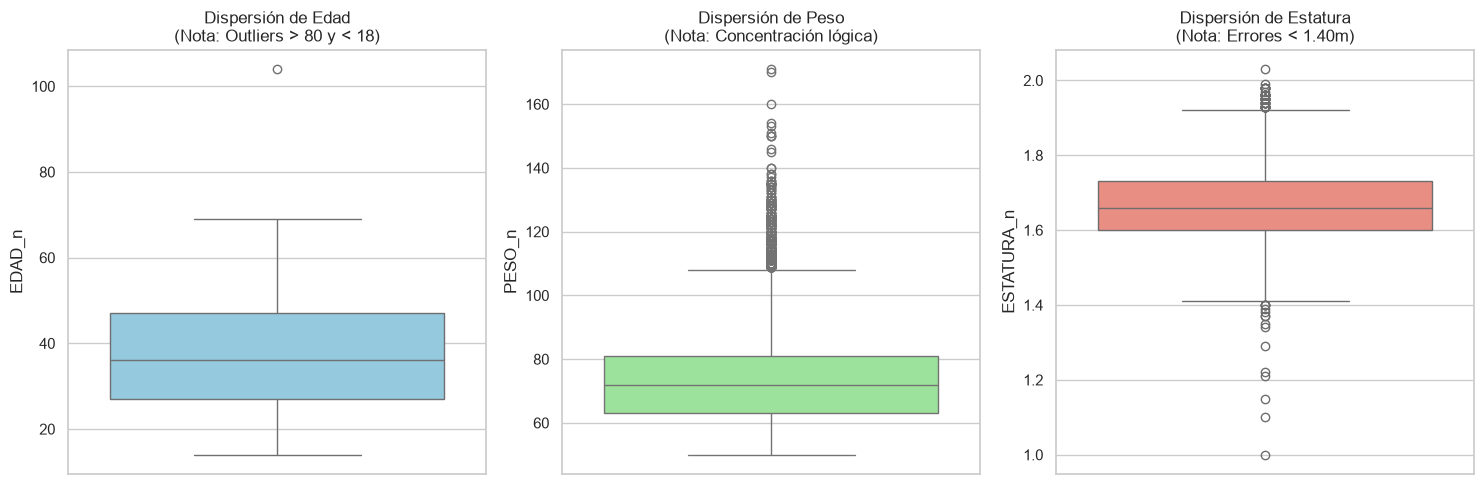

In [21]:
# Celda de código
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df['EDAD_n'], ax=axes[0], color='skyblue')
axes[0].set_title('Dispersión de Edad\n(Nota: Outliers > 80 y < 18)')

sns.boxplot(y=df['PESO_n'], ax=axes[1], color='lightgreen')
axes[1].set_title('Dispersión de Peso\n(Nota: Concentración lógica)')

sns.boxplot(y=df['ESTATURA_n'], ax=axes[2], color='salmon')
axes[2].set_title('Dispersión de Estatura\n(Nota: Errores < 1.40m)')

plt.tight_layout()
plt.show()

**Análisis Visual de Dispersión**
*   Los diagramas de caja confirman que, aunque la mediana de los signos vitales es congruente con la población adulta, las colas de la distribución (puntos fuera de los bigotes) contienen valores físicamente imposibles o legalmente inviables. 
*   La variable `ESTATURA_n` es la más afectada por errores severos de digitación en la cola inferior.

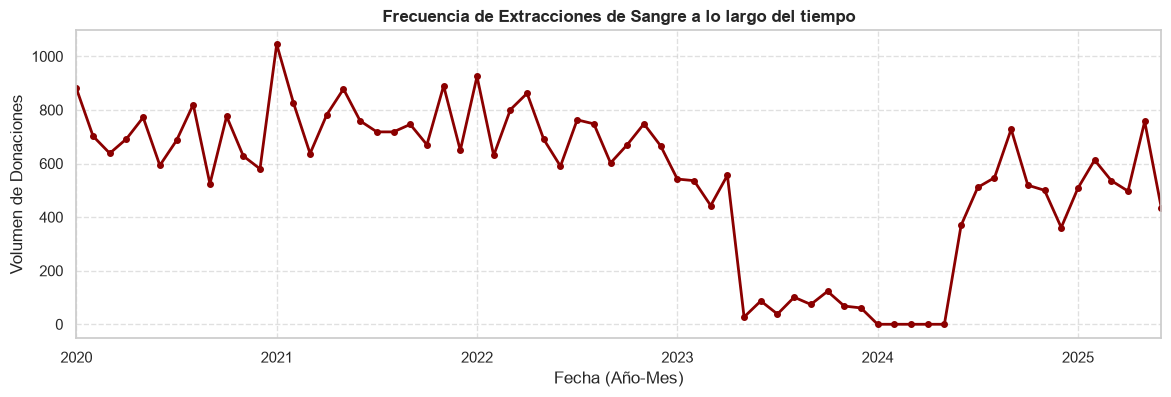

In [22]:
# Agrupar conteo de donaciones por mes y año ('ME' es Month End en pandas)
tendencia = df.dropna(subset=['F_EXT']).set_index('F_EXT').resample('ME').size()

plt.figure(figsize=(14, 4))
tendencia.plot(color='darkred', linewidth=2, marker='o', markersize=4)
plt.title('Frecuencia de Extracciones de Sangre a lo largo del tiempo', fontsize=12, fontweight='bold')
plt.xlabel('Fecha (Año-Mes)')
plt.ylabel('Volumen de Donaciones')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Diagnóstico de Consistencia Temporal**

*   **Brecha Estructural (Pérdida de Datos):** La serie temporal evidencia un colapso crítico en los registros a partir de mediados de 2023. Los volúmenes caen de un promedio saludable de 700 donaciones mensuales a valores cercanos a cero, tocando piso nulo absoluto a principios y mediados de 2024. 
*   **Recuperación del Sistema:** Hacia mediados de 2024, la captura de datos se restaura abruptamente, normalizando los volúmenes en el rango de 500 a 700 extracciones mensuales.
*   **Impacto Analítico:** Esta anomalía no representa la realidad operativa del Hospital General (un banco de sangre no deja de operar un año entero). Indica una **falla sistémica masiva en el origen**: un error en la exportación del CSV, una migración fallida de software en el hospital o una desconexión temporal de la base de datos.
*   **Decisión:** Esta ventana de tiempo (mid 2023 - mid 2024) está contaminada. Si el objetivo futuro de la tesis es hacer modelos de pronóstico de series temporales (forecasting), este hueco arruinará el algoritmo. Deberá documentarse ante los *stakeholders* y requerirá un tratamiento especializado en la etapa de modelado (exclusión del periodo o variables de control por interrupción).